In [9]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [83]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler 
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import KFold, train_test_split, GridSearchCV
 
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
import sklearn.cluster as sk_cluster
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, confusion_matrix, accuracy_score, classification_report
from sklearn.manifold import TSNE

ModuleNotFoundError: No module named 'umap'

In [93]:
!pip install umap-learn

In [95]:
import umap.umap_ as umap

ModuleNotFoundError: No module named 'umap'

In [13]:
from PIL import Image, ImageOps

In [15]:
# Adjust the path to match your Box sync folder location
box_path = os.path.expanduser(r"C:\Users\HIALAB\Box\Human_AGV_project\ISU_Modeling\Code")

In [17]:
# Specify the directory and filename
save_dir = "./trial_images/"

In [19]:
study_data_by_sec = pd.read_csv(os.path.join(box_path, 'study_data_processed.csv'))
study_data_by_sec

,User_X,User_Y,User_Z,User_Pitch,User_Yaw,User_Roll,U_X,U_Y,U_Z,GazeOrigin_X,...,AGV_Yaw,AGV_Roll,AGV_spd,Timestamp,AGVname,PID,DRate,User_Relative_Speed,AGV_Relative_Speed,AGV_User_distance
0,5051.235,8610.830,-209.725,-21.416662,-92.196247,-0.159610,60.524000,-107.387000,156.022000,4990.711200,...,89.999444,0.002393,0.000238,2024-10-25 15:02:48.900,1,1,High,0.0,0.000000,6812.026513
1,5051.235,8610.830,-209.725,-21.168361,-92.384752,0.290698,60.493000,-108.133857,156.034571,4990.742143,...,89.999339,-0.000460,0.154715,2024-10-25 15:02:49.000,1,1,High,0.0,84.241150,6811.521389
2,5051.235,8610.830,-209.725,-21.240655,-92.761660,0.339485,60.271857,-108.963714,156.053429,4990.963429,...,89.999565,-0.001784,0.526054,2024-10-25 15:02:49.100,1,1,High,0.0,74.712591,6809.601293
3,5051.235,8610.830,-209.725,-21.004733,-93.120707,0.251285,59.831714,-109.665143,156.194286,4991.403286,...,90.000198,-0.001954,0.893006,2024-10-25 15:02:49.200,1,1,High,0.0,35.834089,6806.150079
4,5051.235,8610.830,-209.725,-20.717933,-91.225685,0.512156,59.295143,-110.065286,156.430571,4991.940286,...,90.001157,-0.001464,1.263035,2024-10-25 15:02:49.300,1,1,High,0.0,66.574460,6801.168018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6848366,4814.045,8544.847,-209.725,9.361614,-83.257447,2.434928,-57.158167,-36.919167,162.815000,4871.203000,...,56.090021,-0.034390,0.000980,2024-10-25 17:11:16.500,16,46,Low,0.0,0.237071,3572.199178
6848367,4814.045,8544.847,-209.725,8.837808,-85.161383,1.814595,-57.379333,-36.885333,162.748167,4871.424000,...,56.092403,-0.034348,0.001081,2024-10-25 17:11:16.600,16,46,Low,0.0,0.228819,3572.182128
6848368,4814.045,8544.847,-209.725,8.142000,-88.676587,0.913597,-57.698500,-36.836667,162.646667,4871.743000,...,56.094889,-0.034428,0.000787,2024-10-25 17:11:16.700,16,46,Low,0.0,0.239264,3572.164349
6848369,4814.045,8544.847,-209.725,7.388442,-92.010121,0.207441,-57.935833,-36.714167,162.534667,4871.980333,...,56.097355,-0.034399,0.000931,2024-10-25 17:11:16.800,16,46,Low,0.0,0.242956,3572.146282


In [20]:
study_data_by_sec.columns

Index(['User_X', 'User_Y', 'User_Z', 'User_Pitch', 'User_Yaw', 'User_Roll',
       'U_X', 'U_Y', 'U_Z', 'GazeOrigin_X', 'GazeOrigin_Y', 'GazeOrigin_Z',
       'GazeDirection_X', 'GazeDirection_Y', 'GazeDirection_Z', 'Confidence',
       'Gaze_on_AGV', 'AGV_X', 'AGV_Y', 'AGV_Z', 'AGV_Pitch', 'AGV_Yaw',
       'AGV_Roll', 'AGV_spd', 'Timestamp', 'AGVname', 'PID', 'DRate',
       'User_Relative_Speed', 'AGV_Relative_Speed', 'AGV_User_distance'],
      dtype='object')

In [21]:
# Get the total number of null values in each column
null_counts = study_data_by_sec.isnull().sum()
null_counts

User_X                 0
User_Y                 0
User_Z                 0
User_Pitch             0
User_Yaw               0
User_Roll              0
U_X                    0
U_Y                    0
U_Z                    0
GazeOrigin_X           0
GazeOrigin_Y           0
GazeOrigin_Z           0
GazeDirection_X        0
GazeDirection_Y        0
GazeDirection_Z        0
Confidence             0
Gaze_on_AGV            0
AGV_X                  0
AGV_Y                  0
AGV_Z                  0
AGV_Pitch              0
AGV_Yaw                0
AGV_Roll               0
AGV_spd                0
Timestamp              0
AGVname                0
PID                    0
DRate                  0
User_Relative_Speed    0
AGV_Relative_Speed     0
AGV_User_distance      0
dtype: int64

In [22]:
data = pd.read_csv(os.path.join(box_path, 'Per_Interaction_Data_Merged.csv'))
data.head(20)

,PID,DRate,date,hr,min,s,AGVname,StartTime,EndTime,GazeDuration,...,AGV_Path_Complexity,Trust_before,Cross_First_Flag,User_Relative_Speed,AGV_Relative_Speed,Frechet_Distance_3,Frechet_Distance_5,Frechet_Distance_7,Frechet_Distance_10,Cross_First
0,1,High,2024-5-3,14,28,53,1,1900-01-01 15:02:48,1900-01-01 15:03:38,219,...,Straight,4.9,True,74.580213,100.420508,730.13,1188.92,1532.83,1771.61,N\A
1,1,High,2024-5-3,14,28,53,2,1900-01-01 15:03:47,1900-01-01 15:04:29,0,...,Complex,10.0,True,47.888087,232.345812,14.56,97.05,108.21,247.34,N\A
2,1,High,2024-5-3,14,28,53,3,1900-01-01 15:04:37,1900-01-01 15:05:34,268,...,Complex,10.0,True,63.130599,120.176130,282.09,482.54,821.32,1067.08,User
3,1,High,2024-5-3,14,28,53,4,1900-01-01 15:05:46,1900-01-01 15:06:37,779,...,Complex,10.0,True,43.571998,263.284416,421.34,544.15,577.55,610.84,User
4,1,High,2024-5-3,14,28,53,5,1900-01-01 15:06:41,1900-01-01 15:07:44,868,...,Complex,7.0,True,93.720008,91.614207,486.65,852.85,1225.51,1722.14,N\A
5,1,High,2024-5-3,14,28,53,6,1900-01-01 15:07:56,1900-01-01 15:08:58,1195,...,Complex,5.0,True,60.027827,106.258645,560.04,838.76,1112.20,1473.42,N\A
6,1,High,2024-5-3,14,28,53,7,1900-01-01 15:09:07,1900-01-01 15:09:50,537,...,Straight,7.0,True,62.064945,228.573947,379.71,540.52,665.30,941.60,User
7,1,High,2024-5-3,14,28,53,8,1900-01-01 15:10:07,1900-01-01 15:11:08,650,...,Straight,8.0,True,59.394993,161.124764,331.78,693.33,1038.91,1483.72,User
8,1,High,2024-5-3,14,28,53,9,1900-01-01 15:11:12,1900-01-01 15:12:13,856,...,Straight,4.0,True,59.041137,161.124877,115.79,379.19,541.15,1029.62,AGV
9,1,High,2024-5-3,14,28,53,10,1900-01-01 15:12:20,1900-01-01 15:13:08,673,...,Straight,9.0,True,59.998630,205.597358,283.86,567.07,896.84,1312.11,AGV


In [54]:
data[['PID', 'DRate','AGVname','Trust','MWL']].head(20)

,PID,DRate,AGVname,Trust,MWL
0,1,High,1,10,63.0
1,1,High,2,10,63.0
2,1,High,3,10,63.0
3,1,High,4,7,63.0
4,1,High,5,5,63.0
5,1,High,6,7,63.0
6,1,High,7,8,63.0
7,1,High,8,4,63.0
8,1,High,9,9,63.0
9,1,High,10,6,63.0


In [27]:
data.columns

Index(['PID', 'DRate', 'date', 'hr', 'min', 's', 'AGVname', 'StartTime',
       'EndTime', 'GazeDuration', 'mean_dist', 'min_dist', 'max_dist',
       'std_dist', 'mean_agv_spd', 'min_agv_spd', 'max_agv_spd', 'std_spd',
       'task', 'Trust', 'Safe', 'Comfort', 'Expect', 'Age', 'Gender',
       'Ethnicity', 'GamingFrequency', 'VRExperience', 'VRHeadsetExperience',
       'AGVInteraction', 'PerfectAutomation', 'TrustPropensity',
       'AutomationExperience', 'Trust1', 'Trust2', 'MWL', 'Assessment',
       'Gaze_on_AGV', 'User_Trajectory', 'AGV_Approaching',
       'AGV_User_Combination', 'AGV_Path_Complexity', 'Trust_before',
       'Cross_First_Flag', 'User_Relative_Speed', 'AGV_Relative_Speed',
       'Frechet_Distance_3', 'Frechet_Distance_5', 'Frechet_Distance_7',
       'Frechet_Distance_10', 'Cross_First'],
      dtype='object')

In [29]:
null_counts = data.isnull().sum()
null_counts

PID                        0
DRate                      0
date                       0
hr                         0
min                        0
s                          0
AGVname                    0
StartTime                  0
EndTime                    0
GazeDuration               0
mean_dist                  0
min_dist                   0
max_dist                   0
std_dist                   0
mean_agv_spd               0
min_agv_spd                0
max_agv_spd                0
std_spd                    0
task                       0
Trust                      0
Safe                       0
Comfort                    0
Expect                     0
Age                        0
Gender                     0
Ethnicity                  0
GamingFrequency            0
VRExperience               0
VRHeadsetExperience        0
AGVInteraction             0
PerfectAutomation          0
TrustPropensity            0
AutomationExperience       0
Trust1                     0
Trust2        

In [31]:
study_data_by_sec[['User_X', 'User_Y', 'User_Z']].agg(['min', 'max'])

,User_X,User_Y,User_Z
min,1258.016286,5163.372571,-211.874
max,16873.779286,11037.616000,-196.869


In [33]:
# Step 1: Copy the original dataset
RGB_experiment = study_data_by_sec.copy()

# Step 2: Define the original ranges
x_min, x_max = RGB_experiment['User_X'].min(), RGB_experiment['User_X'].max()
y_min, y_max = RGB_experiment['User_Y'].min(), RGB_experiment['User_Y'].max()

# Step 3: Define target image resolution
target_width = 300
target_height = 200

# Step 4: Normalize and round to nearest pixel
RGB_experiment['User_X'] = ((RGB_experiment['User_X'] - x_min) / (x_max - x_min) * target_width).round().astype(int)
RGB_experiment['User_Y'] = ((RGB_experiment['User_Y'] - y_min) / (y_max - y_min) * target_height).round().astype(int)

## Normalize each column in range [0, 255]

In [36]:
# Columns to normalize between 0 and 255
columns_to_normalize = ['User_Pitch', 'User_Yaw', 'User_Roll',
       'GazeOrigin_X', 'GazeOrigin_Y', 'GazeOrigin_Z',
       'GazeDirection_X', 'GazeDirection_Y', 'GazeDirection_Z', 
        'AGV_X', 'AGV_Y', 'AGV_Z', 'AGV_Pitch', 'AGV_Yaw',
       'AGV_Roll', 'AGV_spd',
       'User_Relative_Speed', 'AGV_Relative_Speed', 'AGV_User_distance']

# Normalize each column in place to range [0, 255]
for col in columns_to_normalize:
    col_min = RGB_experiment[col].min()
    col_max = RGB_experiment[col].max()
    RGB_experiment[col] = ((RGB_experiment[col] - col_min) / (col_max - col_min) * 255).round().astype(int)

In [37]:
def generate_rgb_images(data, agv_name, d_rate, r_col, g_col, b_col,
                        save_dir, width=300, height=200,
                        border_thickness=1, border_color=(0, 0, 0),
                        show=True):
    """
    Generate and save RGB images per PID using R, G, B channels.
    Optionally display each image with `show=True`.
    """
    os.makedirs(save_dir, exist_ok=True)
    
    filtered_data = data[(data['AGVname'] == agv_name) & (data['DRate'] == d_rate)]
    unique_pids = filtered_data['PID'].unique()

    for pid in unique_pids:
        pid_data = filtered_data[filtered_data['PID'] == pid]

        # Create empty white channels
        red_channel = np.ones((height, width), dtype=np.uint8) * 255
        green_channel = np.ones((height, width), dtype=np.uint8) * 255
        blue_channel = np.ones((height, width), dtype=np.uint8) * 255

        count = 0
        for _, row in pid_data.iterrows():
            x = int(row['User_X'])
            y = int(row['User_Y'])
            if 0 <= x < width and 0 <= y < height:
                red_channel[y, x] = row[r_col]
                green_channel[y, x] = row[g_col]
                blue_channel[y, x] = row[b_col]
                count += 1

        print(f"Plotted {count} pixels for PID {pid}")

        # Create RGB image with optional border
        rgb_image = np.stack([red_channel, green_channel, blue_channel], axis=-1)
        img = Image.fromarray(rgb_image, 'RGB')
        img_with_border = ImageOps.expand(img, border=border_thickness, fill=border_color)

        # Save image
        filename = f"{pid}_{agv_name}_{d_rate}.png"
        save_path = os.path.join(save_dir, filename)
        img_with_border.save(save_path)
        print(f"Saved image to: {save_path}")

        # Optionally display
        if show:
            display_img = img_with_border.resize((300, 200), resample=Image.NEAREST)
            plt.figure(figsize=(6, 4))
            plt.imshow(display_img)
            plt.title(f'PID {pid} | AGV {agv_name} | DRate {d_rate}')
            plt.axis('off')
            plt.tight_layout()
            plt.show()

In [40]:
RGB_experiment[['User_Relative_Speed', 'AGV_Relative_Speed', 'AGV_User_distance', 'User_X', 'User_Y']].agg(['min', 'max'])

,User_Relative_Speed,AGV_Relative_Speed,AGV_User_distance,User_X,User_Y
min,0,0,0,0,0
max,255,255,255,300,200


In [ ]:
generate_rgb_images(
    data=RGB_experiment,
    agv_name=3,
    d_rate='High',
    r_col='User_Relative_Speed',
    g_col='GazeDirection_X',
    b_col='AGV_User_distance',
    save_dir='per_trial_images',
    show=False  # Set to True if you want to view each image
)

### Labeling the Dataset

In [43]:
def build_image_label_mapping(image_dir, data):
    """
    Create a DataFrame with columns:
    ['image_path', 'trust', 'PID', 'AGVname', 'DRate']
    by parsing image filenames and joining with the `data` DataFrame.
    """
    rows = []

    for filename in os.listdir(image_dir):
        if not filename.endswith(".png"):
            continue

        try:
            pid_str, agvname_str, drate_with_ext = filename.split('_')
            drate = drate_with_ext.replace(".png", "")
            pid = int(pid_str)
            agvname = int(agvname_str)
        except Exception as e:
            print(f"Skipping file {filename}: {e}")
            continue

        # Look up Trust value
        match = data[
            (data['PID'] == pid) &
            (data['AGVname'] == agvname) &
            (data['DRate'] == drate)
        ]

        if not match.empty:
            trust = match['Trust'].values[0]
            image_path = os.path.join(image_dir, filename)
            rows.append({
                'image_path': image_path,
                'trust': trust,
                'PID': pid,
                'AGVname': agvname,
                'DRate': drate
            })
        else:
            print(f"No trust value found for: PID={pid}, AGVname={agvname}, DRate={drate}")

    return pd.DataFrame(rows)

In [45]:
image_dir = "./trial_images/"
image_label_df = build_image_label_mapping(image_dir=image_dir, data=data)

In [47]:
image_label_df['DRate'] = pd.Categorical(
    image_label_df['DRate'],
    categories=['High', 'Low'],
    ordered=True
)

# Sort by PID, AGVname, DRate
image_label_df = image_label_df.sort_values(by=['PID', 'AGVname', 'DRate']).reset_index(drop=True)

In [49]:
image_label_df.head(20)

,image_path,trust,PID,AGVname,DRate
0,./trial_images/1_1_High.png,10,1,1,High
1,./trial_images/1_1_Low.png,5,1,1,Low
2,./trial_images/1_2_High.png,10,1,2,High
3,./trial_images/1_2_Low.png,7,1,2,Low
4,./trial_images/1_3_High.png,10,1,3,High
5,./trial_images/1_3_Low.png,7,1,3,Low
6,./trial_images/1_4_High.png,7,1,4,High
7,./trial_images/1_4_Low.png,8,1,4,Low
8,./trial_images/1_5_High.png,5,1,5,High
9,./trial_images/1_5_Low.png,9,1,5,Low


In [51]:
def visualize_and_save_user_trials(data, r_col, g_col, b_col,
                                   save_dir='experiment_images',
                                   width=300, height=200,
                                   show=False):
    """
    For each PID, generate and save RGB images for High and Low DRates separately.
    Saves each as {PID}_{DRate}.png in the specified save_dir.
    Optionally displays each image as well.
    """
    os.makedirs(save_dir, exist_ok=True)

    for pid in data['PID'].unique():
        for d_rate in ['High', 'Low']:
            subset = data[(data['PID'] == pid) & (data['DRate'] == d_rate)]
            if subset.empty:
                continue

            # Create white background
            red_channel = np.ones((height, width), dtype=np.uint8) * 255
            green_channel = np.ones((height, width), dtype=np.uint8) * 255
            blue_channel = np.ones((height, width), dtype=np.uint8) * 255

            for _, row in subset.iterrows():
                x = int(row['User_X'])
                y = int(row['User_Y'])
                if 0 <= x < width and 0 <= y < height:
                    red_channel[y, x] = row[r_col]
                    green_channel[y, x] = row[g_col]
                    blue_channel[y, x] = row[b_col]

            # Convert to image and save
            rgb_array = np.stack([red_channel, green_channel, blue_channel], axis=-1)
            img = Image.fromarray(rgb_array, 'RGB')
            save_path = os.path.join(save_dir, f"{pid}_{d_rate}.png")
            img.save(save_path)
            print(f"Saved: {save_path}")

            if show:
                plt.figure(figsize=(6, 4))
                plt.imshow(img)
                plt.title(f"PID {pid} | DRate: {d_rate}")
                plt.axis('off')
                plt.tight_layout()
                plt.show()

In [53]:
visualize_and_save_user_trials(
    data=RGB_experiment,
    r_col='User_Relative_Speed',
    g_col='GazeDirection_X',
    b_col='AGV_User_distance',
    save_dir='experiment_images',
    show=False  # Set to True to display each image while saving
)

Saved: experiment_images\1_High.png
Saved: experiment_images\1_Low.png
Saved: experiment_images\2_High.png
Saved: experiment_images\2_Low.png
Saved: experiment_images\3_High.png
Saved: experiment_images\3_Low.png
Saved: experiment_images\4_High.png
Saved: experiment_images\4_Low.png
Saved: experiment_images\6_High.png
Saved: experiment_images\6_Low.png
Saved: experiment_images\7_High.png
Saved: experiment_images\7_Low.png
Saved: experiment_images\8_High.png
Saved: experiment_images\8_Low.png
Saved: experiment_images\9_High.png
Saved: experiment_images\9_Low.png
Saved: experiment_images\10_High.png
Saved: experiment_images\10_Low.png
Saved: experiment_images\11_High.png
Saved: experiment_images\11_Low.png
Saved: experiment_images\12_High.png
Saved: experiment_images\12_Low.png
Saved: experiment_images\13_High.png
Saved: experiment_images\13_Low.png
Saved: experiment_images\14_High.png
Saved: experiment_images\14_Low.png
Saved: experiment_images\15_High.png
Saved: experiment_images\15_Lo

In [79]:
def load_and_vectorize_images(image_paths, image_size=(64, 64)):
    vectors = []
    for path in image_paths:
        img = Image.open(path).convert("RGB").resize(image_size)
        img_arr = np.asarray(img).astype(np.float32) / 255.0
        vectors.append(img_arr.flatten())
    return np.array(vectors)

In [89]:
# Load image paths
image_dir = "experiment_images"
image_paths = sorted([os.path.join(image_dir, f) for f in os.listdir(image_dir) if f.endswith(".png")])

# Convert images to flat vectors
X = load_and_vectorize_images(image_paths)

# Apply UMAP for nonlinear dimensionality reduction
umap_embedder = umap.UMAP(n_components=2, random_state=42)
X_umap = umap_embedder.fit_transform(X)

# Optional: apply KMeans to the UMAP embedding
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X_umap)

NameError: name 'umap' is not defined

In [69]:
def plot_clustered_images(image_paths, labels, n_per_cluster=5):
    unique_labels = np.unique(labels)
    for label in unique_labels:
        cluster_indices = np.where(labels == label)[0][:n_per_cluster]
        plt.figure(figsize=(15, 3))
        for i, idx in enumerate(cluster_indices):
            img = Image.open(image_paths[idx])
            plt.subplot(1, n_per_cluster, i+1)
            plt.imshow(img)
            plt.axis('off')
        plt.suptitle(f"Cluster {label}", fontsize=14)
        plt.tight_layout()
        plt.show()

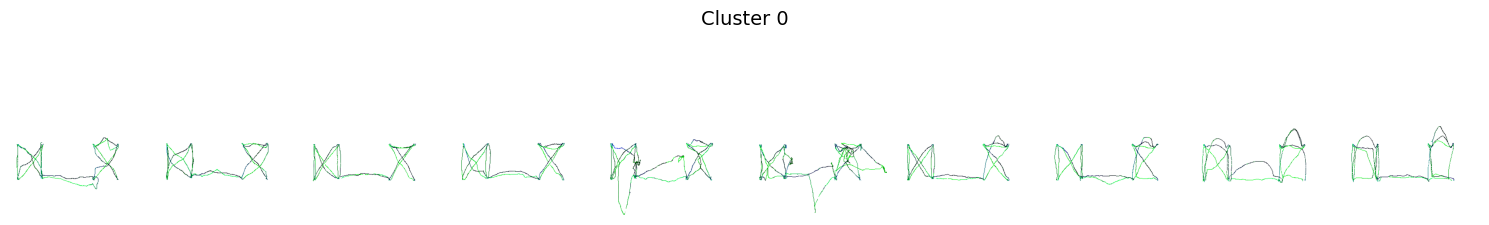

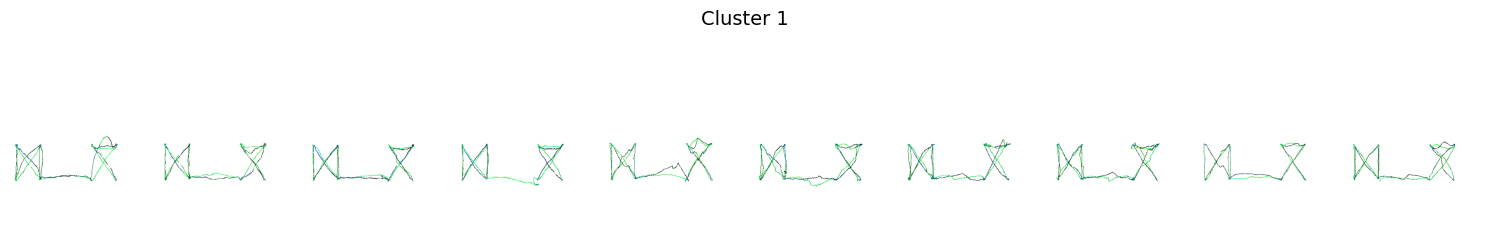

In [75]:
plot_clustered_images(image_paths, labels, n_per_cluster=10)

In [40]:
# Step 1: Copy the original dataset
per_trial_RGB_experiment = study_data_by_sec.copy()

# Step 2: Define target image resolution
target_width = 300
target_height = 200

# Step 3: Normalize User_X and User_Y **within each (AGVname, DRate) group**
for (agvname), group_indices in per_trial_RGB_experiment.groupby(['AGVname']).groups.items():
    subset = per_trial_RGB_experiment.loc[group_indices]

    x_min, x_max = subset['User_X'].min(), subset['User_X'].max()
    y_min, y_max = subset['User_Y'].min(), subset['User_Y'].max()

    # Avoid division by zero in case min == max
    x_range = x_max - x_min if x_max != x_min else 1
    y_range = y_max - y_min if y_max != y_min else 1

    # Normalize to [0, width-1] and [0, height-1], then round
    per_trial_RGB_experiment.loc[group_indices, 'User_X'] = (
        ((subset['User_X'] - x_min) / x_range * (target_width - 1)).round().astype(int)
    )
    per_trial_RGB_experiment.loc[group_indices, 'User_Y'] = (
        ((subset['User_Y'] - y_min) / y_range * (target_height - 1)).round().astype(int)
    )

In [42]:
# Columns to normalize between 0 and 255
columns_to_normalize = ['User_Pitch', 'User_Yaw', 'User_Roll',
       'GazeOrigin_X', 'GazeOrigin_Y', 'GazeOrigin_Z',
       'GazeDirection_X', 'GazeDirection_Y', 'GazeDirection_Z',
       'AGV_X', 'AGV_Y', 'AGV_Z', 'AGV_Pitch', 'AGV_Yaw',
       'AGV_Roll', 'AGV_spd',
       'User_Relative_Speed', 'AGV_Relative_Speed', 'AGV_User_distance'
]

# Normalize each column in place to range [0, 255]
for col in columns_to_normalize:
    col_min = per_trial_RGB_experiment[col].min()
    col_max = per_trial_RGB_experiment[col].max()
    per_trial_RGB_experiment[col] = ((per_trial_RGB_experiment[col] - col_min) / (col_max - col_min) * 255).round().astype(int)

NameError: name 'RGB_experiment' is not defined

### Stack All PID Images into One

In [ ]:
def generate_stacked_rgb_image(data, d_rate, r_col, g_col, b_col,
                        width=300, height=200):
    """
    Overlay RGB images for each PID into one single image canvas.
    Each pixel gets overwritten if hit again (last one wins).
    """
    filtered_data = data[(data['AGVname'] == agv_name) & (data['DRate'] == d_rate)]
    unique_pids = filtered_data['PID'].unique()

    # Start with a white background canvas
    red_channel = np.ones((height, width), dtype=np.uint8) * 255
    green_channel = np.ones((height, width), dtype=np.uint8) * 255
    blue_channel = np.ones((height, width), dtype=np.uint8) * 255

    total_pixels = 0

    for pid in unique_pids:
        pid_data = filtered_data[filtered_data['PID'] == pid]

        for _, row in pid_data.iterrows():
            x = int(row['User_X'])
            y = int(row['User_Y'])
            if 0 <= x < width and 0 <= y < height:
                red_channel[y, x] = row[r_col]
                green_channel[y, x] = row[g_col]
                blue_channel[y, x] = row[b_col]
                total_pixels += 1

    print(f"Total pixels plotted from all PIDs: {total_pixels}")

    # Stack into one RGB image
    final_image = np.stack([red_channel, green_channel, blue_channel], axis=-1)

    # Show the image
    plt.figure(figsize=(8, 5))
    plt.imshow(final_image)
    plt.title(f'Overlayed RGB Image | AGV: {agv_name}, DRate: {d_rate}')
    plt.axis('off')
    plt.tight_layout()
    filename = f'per_trial_RGB_experiment_{agv_name}_{d_rate}.png'
    # plt.savefig(save_dir + filename, bbox_inches = 'tight', pad_inches=0.1)
    
    plt.show()
    return final_image

In [ ]:
for pid in range of pids:
    generate_stacked_rgb_image(
        data=per_trial_RGB_experiment,
        agv_name=i,
        d_rate='High',
        r_col='AGV_spd',
        g_col='GazeDirection_X',
        b_col='AGV_User_distance',
    )

In [ ]:
for i in range (1, 17):
    generate_stacked_rgb_image(
        data=per_trial_RGB_experiment,
        agv_name=i,
        d_rate='Low',
        r_col='AGV_spd',
        g_col='GazeDirection_X',
        b_col='AGV_User_distance',
    )